# DeliveryETA — Étape 2 : Exploration et analyse des dépendances (EDA)

Objectif : comprendre ce qui influence `Time_taken(min)`, à partir du dataset nettoyé (étape 1).

In [1]:
import sys
sys.path.append("..")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.features.engineering import engineer_features

sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)

df = pd.read_csv("../data/processed/dataset_delivery_time_clean.csv")
print(df.shape)
df.head()

(41706, 20)


,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min)
0,0x4607,INDORES13DEL02,37.0,4.9,22.745049,75.892471,22.765049,75.912471,2022-03-19,11:30:00,11:45:00,Sunny,High,2,Snack,motorcycle,0.0,No,Urban,24.0
1,0xb379,BANGRES18DEL02,34.0,4.5,12.913041,77.683237,13.043041,77.813237,2022-03-25,19:45:00,19:50:00,Stormy,Jam,2,Snack,scooter,1.0,No,Metropolitian,33.0
2,0x5d6d,BANGRES19DEL01,23.0,4.4,12.914264,77.678400,12.924264,77.688400,2022-03-19,08:30:00,08:45:00,Sandstorms,Low,0,Drinks,motorcycle,1.0,No,Urban,26.0
3,0x7a6a,COIMBRES13DEL02,38.0,4.7,11.003669,76.976494,11.053669,77.026494,2022-04-05,18:00:00,18:10:00,Sunny,Medium,0,Buffet,motorcycle,1.0,No,Metropolitian,21.0
4,0x70a2,CHENRES12DEL01,32.0,4.6,12.972793,80.249982,13.012793,80.289982,2022-03-26,13:30:00,13:45:00,Cloudy,High,1,Snack,scooter,1.0,No,Metropolitian,30.0


## 1. Analyse descriptive

### 1.1 Variables numériques : moyenne, médiane, écart-type

In [2]:
num_cols = ["Delivery_person_Age", "Delivery_person_Ratings", "Vehicle_condition",
            "multiple_deliveries", "Time_taken(min)"]
df[num_cols].describe().T[["mean", "50%", "std", "min", "max"]].rename(columns={"50%": "median"})

,mean,median,std,min,max
Delivery_person_Age,29.566273,30.0,5.694036,15.0,50.0
Delivery_person_Ratings,4.636076,4.7,0.328305,1.0,6.0
Vehicle_condition,1.028413,1.0,0.837460,0.0,3.0
multiple_deliveries,0.746080,1.0,0.560006,0.0,3.0
Time_taken(min),26.153191,25.0,9.179161,10.0,51.0


**Lecture** : l'âge moyen des livreurs est d'environ 30 ans (médiane identique -> distribution symétrique),
la note moyenne est élevée (~4.6/5, peu de dispersion), et le temps de livraison moyen est d'environ 26
minutes avec un écart-type de 9 minutes.

### 1.2 Variables catégorielles : fréquences

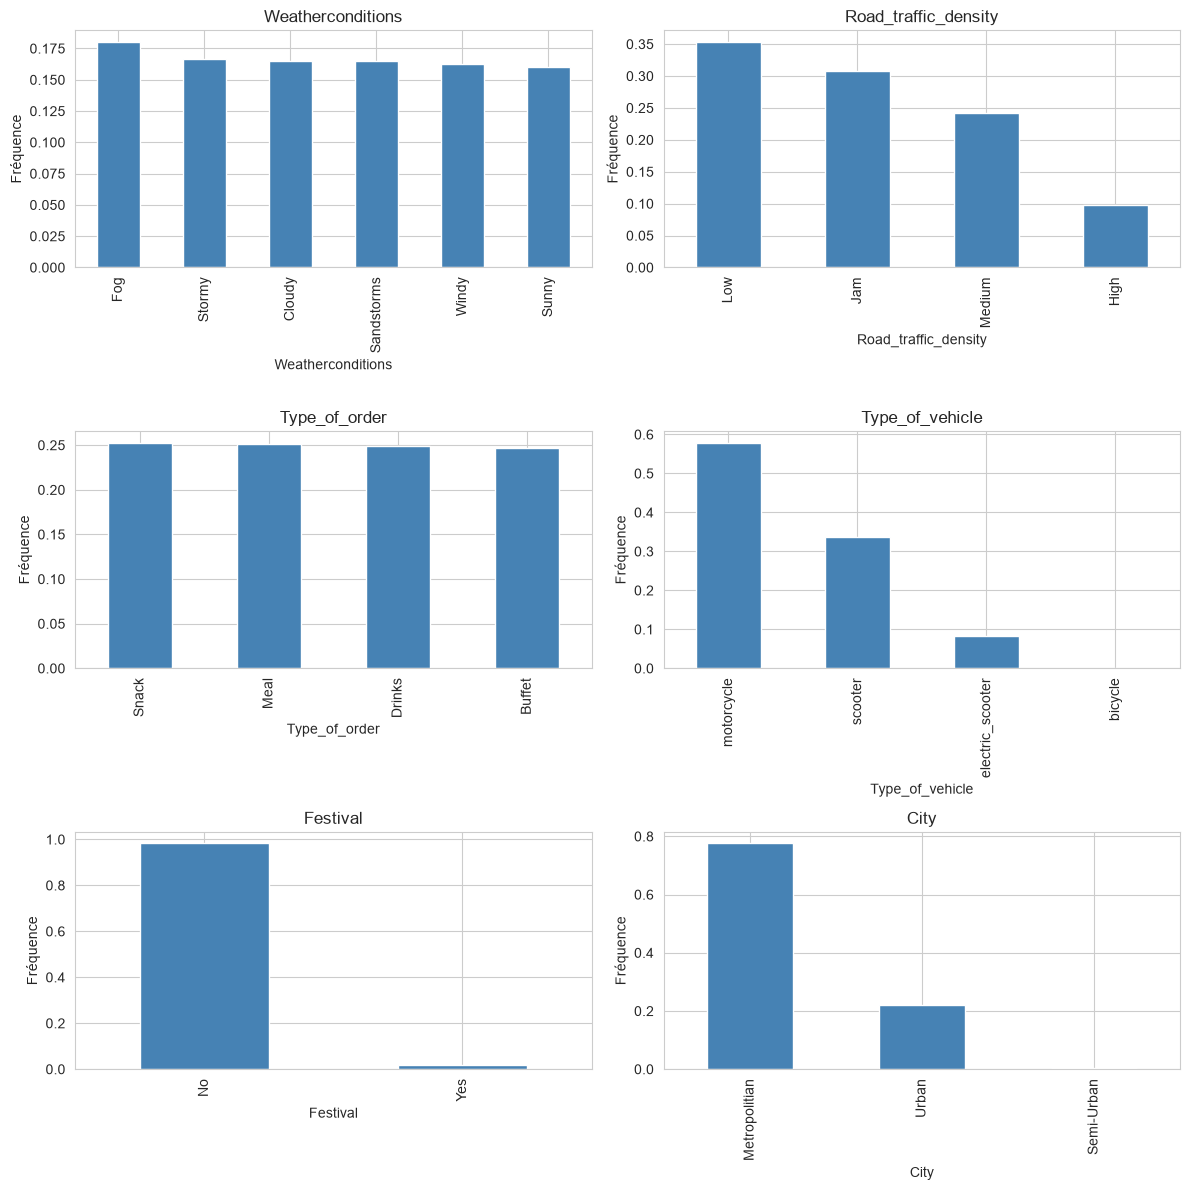

In [3]:
cat_cols = ["Weatherconditions", "Road_traffic_density", "Type_of_order",
            "Type_of_vehicle", "Festival", "City"]

fig, axes = plt.subplots(3, 2, figsize=(12, 12))
for ax, col in zip(axes.ravel(), cat_cols):
    df[col].value_counts(normalize=True).plot(kind="bar", ax=ax, color="steelblue")
    ax.set_title(col)
    ax.set_ylabel("Fréquence")
plt.tight_layout()
plt.show()

**Lecture** :
- `Type_of_order`, `Weatherconditions` sont quasi uniformément répartis (dataset équilibré, pas de biais
  d'échantillonnage évident sur ces variables).
- `Road_traffic_density` : "Low" domine (35 %), "High" est minoritaire (10 %).
- `Type_of_vehicle` : la moto domine (58 %), le vélo est marginal (0,1 %) -> à surveiller en modélisation
  (catégorie très peu représentée, risque d'instabilité de son coefficient/importance).
- `Festival` : "Yes" ne représente que 1,8 % des commandes -> classe très déséquilibrée mais, comme on le
  verra, à fort impact sur la cible.
- `City` : "Semi-Urban" ne représente que 0,2 % des lignes -> tout écart observé sur cette catégorie doit être
  interprété avec prudence (échantillon trop petit).

## 2. Distribution de la variable cible `Time_taken(min)`

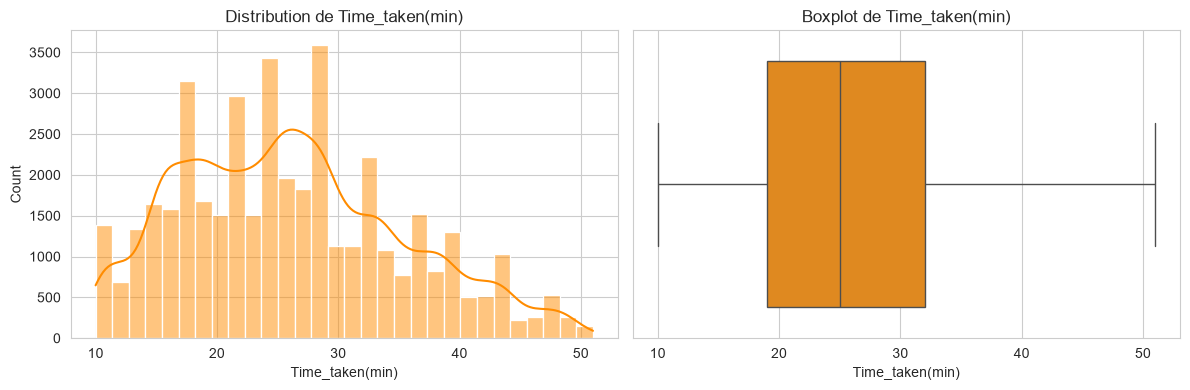

Skewness : 0.422


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df["Time_taken(min)"], bins=30, kde=True, ax=axes[0], color="darkorange")
axes[0].set_title("Distribution de Time_taken(min)")

sns.boxplot(x=df["Time_taken(min)"], ax=axes[1], color="darkorange")
axes[1].set_title("Boxplot de Time_taken(min)")

plt.tight_layout()
plt.show()

print("Skewness :", df["Time_taken(min)"].skew().round(3))

**Interprétation** : la distribution est légèrement asymétrique à droite (skewness ≈ 0.42) : la majorité
des livraisons prennent entre 19 et 32 minutes (IQR), avec une traîne de livraisons plus longues. Ce n'est
pas une asymétrie assez forte pour nécessiter une transformation (log) de la cible, mais cela justifie de
privilégier des métriques robustes (MAE, médiane des erreurs) en complément du RMSE à l'étape 4.

## 3. Relation entre la cible et chaque variable explicative

### 3.1 Variables catégorielles vs cible

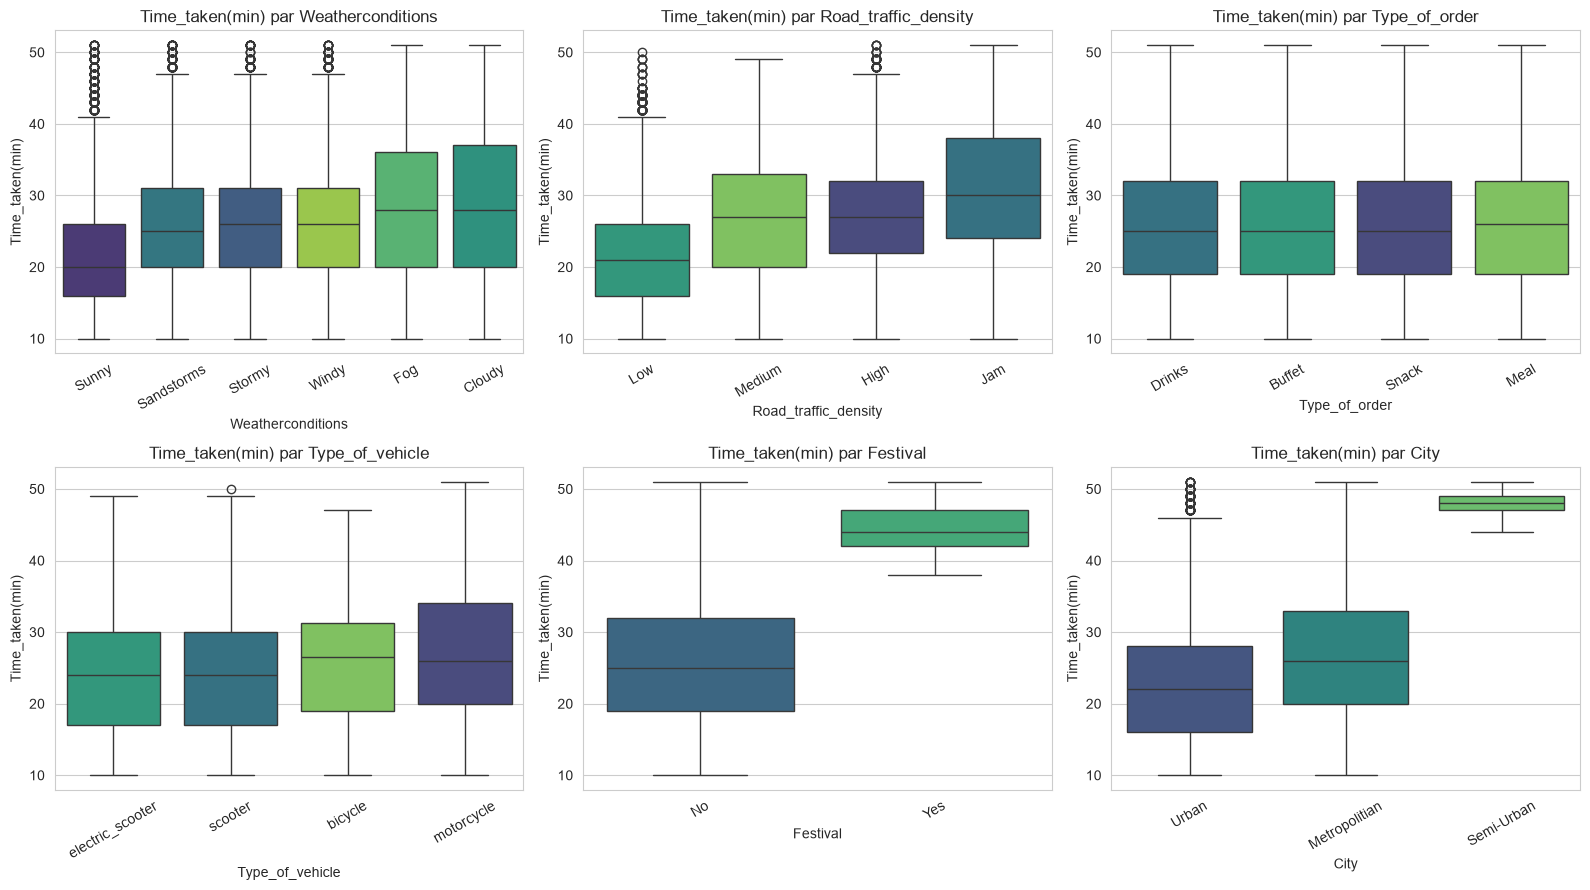

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, col in zip(axes.ravel(), cat_cols):
    order = df.groupby(col)["Time_taken(min)"].mean().sort_values().index
    sns.boxplot(data=df, x=col, y="Time_taken(min)", order=order, hue=col,
                legend=False, ax=ax, palette="viridis")
    ax.set_title(f"Time_taken(min) par {col}")
    ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

**Lecture des écarts de moyenne observés** :

| Variable | Écart observé | Interprétation |
|---|---|---|
| `Road_traffic_density` | 21.5 min (Low) -> 30.8 min (Jam) | Le trafic est un facteur explicatif fort et monotone : plus le trafic est dense, plus la livraison est longue. |
| `Weatherconditions` | 21.7 min (Sunny) -> 28.8 min (Cloudy/Fog) | Mauvaise météo = livraison plus lente, effet net (~+7 min) même si moins fort que le trafic. |
| `Type_of_vehicle` | 24.5 min (scooter/électrique) -> 27.4 min (moto) | Écart modéré ; à interpréter avec prudence pour le vélo (0,1 % des lignes). |
| `Festival` | 25.8 min (No) -> 44.6 min (Yes) | Écart considérable (+19 min), mais sur seulement 1,8 % des commandes : effet fort mais rare. |
| `City` | 23 min (Urban) -> 27 min (Metropolitian) -> 48 min (Semi-Urban) | Le chiffre Semi-Urban repose sur un échantillon minuscule (0,2 %) -> à ne pas surinterpréter. |

### 3.2 Variables numériques vs cible

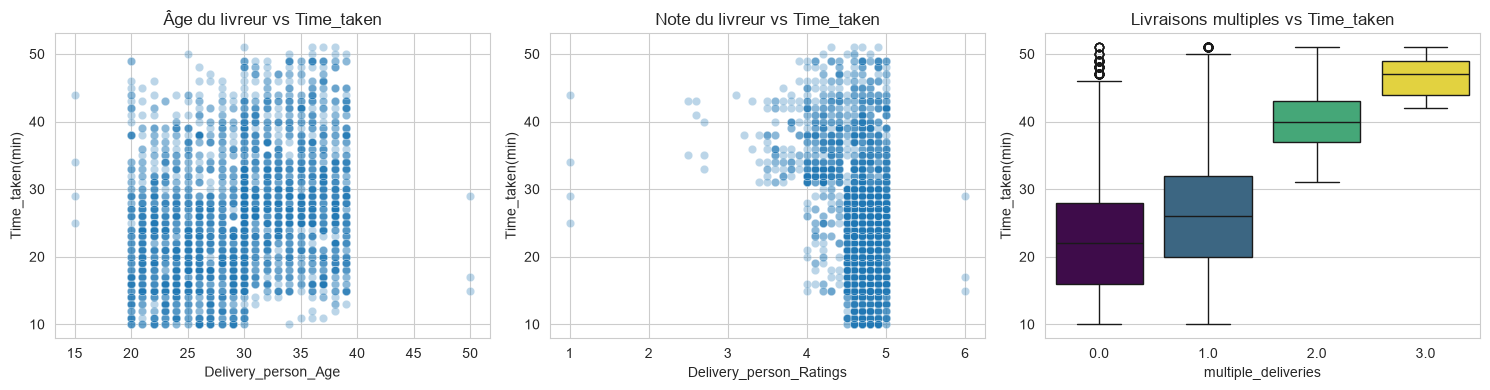

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.scatterplot(data=df.sample(3000, random_state=42), x="Delivery_person_Age",
                 y="Time_taken(min)", alpha=0.3, ax=axes[0])
axes[0].set_title("Âge du livreur vs Time_taken")

sns.scatterplot(data=df.sample(3000, random_state=42), x="Delivery_person_Ratings",
                 y="Time_taken(min)", alpha=0.3, ax=axes[1])
axes[1].set_title("Note du livreur vs Time_taken")

sns.boxplot(data=df, x="multiple_deliveries", y="Time_taken(min)", hue="multiple_deliveries",
            legend=False, ax=axes[2], palette="viridis")
axes[2].set_title("Livraisons multiples vs Time_taken")

plt.tight_layout()
plt.show()

**Interprétation** :
- La note du livreur (`Delivery_person_Ratings`) est corrélée négativement à la cible (livreurs mieux notés
  = plus rapides), cohérent avec l'intuition métier.
- `multiple_deliveries` (nombre de livraisons groupées) augmente clairement le temps : chaque livraison
  supplémentaire dans la tournée retarde la livraison courante.
- L'âge du livreur montre une relation positive plus modérée, à confirmer avec la matrice de corrélation.

## 4. Matrice de corrélation

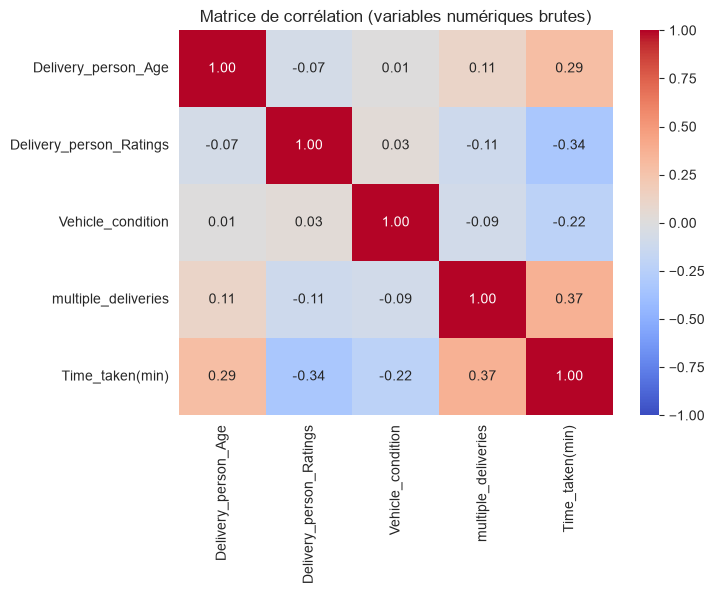

In [7]:
corr_cols = ["Delivery_person_Age", "Delivery_person_Ratings", "Vehicle_condition",
             "multiple_deliveries", "Time_taken(min)"]
corr = df[corr_cols].corr()

plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1)
plt.title("Matrice de corrélation (variables numériques brutes)")
plt.show()

**Interprétation** : parmi les variables numériques disponibles avant feature engineering, `multiple_deliveries`
(+0.37) et `Delivery_person_Ratings` (-0.34) sont les plus corrélées à la cible ; `Vehicle_condition` a un lien
négatif plus modéré (-0.22). Ces corrélations restent modérées prises isolément : c'est attendu, le temps de
livraison dépend surtout d'interactions entre variables (trafic x distance x météo), pas d'une seule variable
linéaire. La matrice sera recalculée après feature engineering (section 6) pour vérifier l'apport des nouvelles
variables.

## 5. Variables les plus fortement liées au temps de livraison

In [8]:
ranking = df[corr_cols].corr()["Time_taken(min)"].drop("Time_taken(min)").abs().sort_values(ascending=False)
ranking

multiple_deliveries        0.368991
Delivery_person_Ratings    0.335163
Delivery_person_Age        0.292329
Vehicle_condition          0.222096
Name: Time_taken(min), dtype: float64

**Constat** : à ce stade (avant feature engineering), le classement par force de corrélation absolue est :
1. `multiple_deliveries` (0.37)
2. `Delivery_person_Ratings` (0.34)
3. `Vehicle_condition` (0.22)
4. `Delivery_person_Age` (0.29 -- proche du n°2, à vérifier après ajout de Distance_km)

Auxquelles s'ajoutent, d'après l'analyse catégorielle (section 3.1), `Road_traffic_density`, `Weatherconditions`
et `Festival` comme facteurs catégoriels à fort pouvoir explicatif, malgré l'absence de coefficient de
corrélation linéaire pour ces variables non numériques.

## 6. Feature engineering

Trois nouvelles variables sont créées via `src/features/engineering.py` :

1. **`Distance_km`** (Haversine restaurant -> client) : la distance n'existe pas explicitement dans les
   données brutes (seulement 4 coordonnées GPS), alors qu'elle est un déterminant physique évident du temps
   de trajet.
2. **`Preparation_time_min`** (Time_Order_picked - Time_Orderd, plafonné à 60 min) : isole le temps de
   préparation en cuisine, potentiellement distinct du temps de trajet lui-même.
3. **`Order_hour`, `Day_of_week`, `Is_weekend`** : capte un éventuel effet d'heure de pointe ou de
   jour de la semaine non porté par `Road_traffic_density` seul.

In [9]:
df_feat = engineer_features(df)
df_feat[["Distance_km", "Preparation_time_min", "Order_hour", "Day_of_week", "Is_weekend"]].describe()

,Distance_km,Preparation_time_min,Order_hour,Day_of_week,Is_weekend
count,41706.000000,41706.000000,41706.000000,41706.000000,41706.000000
mean,9.699130,11.769410,17.545701,2.994293,0.275284
std,5.601902,10.053927,4.781081,1.970412,0.446663
min,1.465067,0.000000,0.000000,0.000000,0.000000
25%,4.657620,5.000000,15.000000,1.000000,0.000000
50%,9.192686,10.000000,19.000000,3.000000,0.000000
75%,13.631416,15.000000,21.000000,5.000000,1.000000
max,20.969489,60.000000,23.000000,6.000000,1.000000


In [10]:
new_feats = ["Distance_km", "Preparation_time_min", "Order_hour", "Is_weekend"]
corr_new = df_feat[new_feats + ["Time_taken(min)"]].corr()["Time_taken(min)"].drop("Time_taken(min)")
corr_new.sort_values(key=abs, ascending=False)

Distance_km             0.318515
Order_hour              0.176776
Is_weekend             -0.006110
Preparation_time_min   -0.005487
Name: Time_taken(min), dtype: float64

**Interprétation des nouvelles features** :
- `Distance_km` (0.32) rejoint immédiatement le trio de tête des variables numériques -- confirme
  l'hypothèse métier : plus la distance est grande, plus la livraison est longue.
- `Order_hour` (0.18) a un effet modéré mais réel : certaines heures de la journée (probablement les pics de
  repas) allongent le temps de livraison au-delà du seul effet du trafic déclaré.
- `Preparation_time_min` (~0.01 après plafonnement) et `Is_weekend` (~0.00) n'apportent presque aucun signal
  linéaire direct. On les garde tout de même dans le dataset (elles pourront s'avérer utiles en interaction
  avec d'autres variables, ou lors d'un feature engineering plus poussé), mais on ne s'attend pas à ce
  qu'elles pèsent lourd dans l'importance des variables du modèle final -- c'est un résultat honnête de
  l'analyse, pas un échec du feature engineering : toute variable créée n'est pas obligée d'être prédictive.

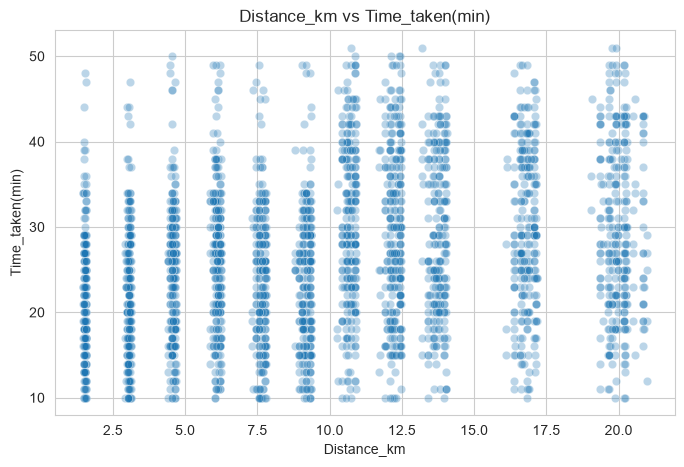

In [11]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df_feat.sample(3000, random_state=42), x="Distance_km", y="Time_taken(min)", alpha=0.3)
plt.title("Distance_km vs Time_taken(min)")
plt.show()

## 7. Matrice de corrélation finale (avec les nouvelles features)

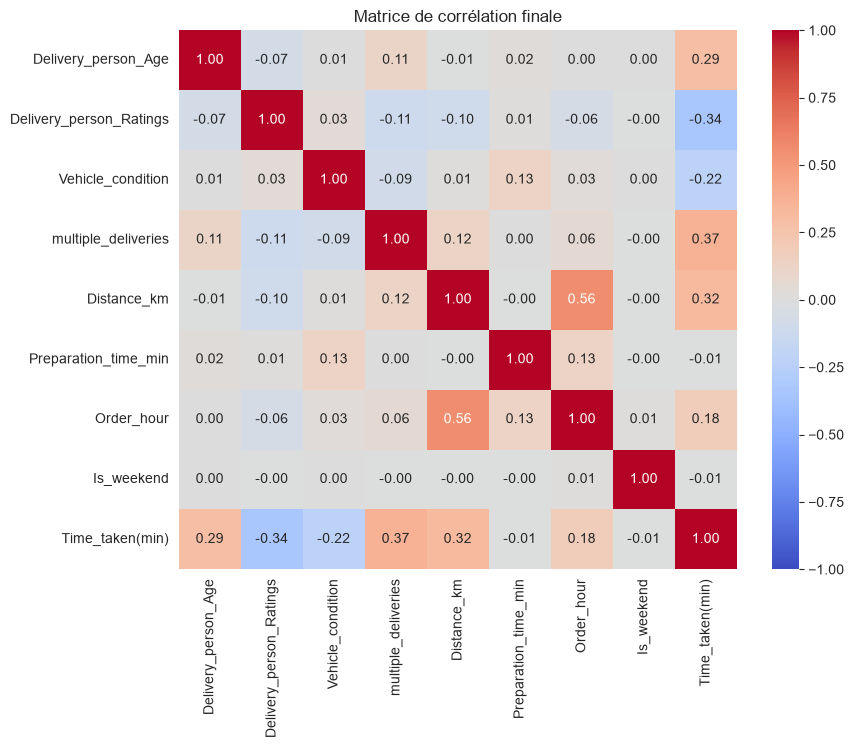

In [12]:
final_cols = ["Delivery_person_Age", "Delivery_person_Ratings", "Vehicle_condition",
              "multiple_deliveries", "Distance_km", "Preparation_time_min",
              "Order_hour", "Is_weekend", "Time_taken(min)"]

plt.figure(figsize=(9, 7))
sns.heatmap(df_feat[final_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1)
plt.title("Matrice de corrélation finale")
plt.show()

**Conclusion de l'EDA** : les variables les plus fortement liées au temps de livraison sont, par ordre
décroissant d'impact observé : `Festival` et `Road_traffic_density` (effet catégoriel fort), `multiple_deliveries`,
`Delivery_person_Ratings`, `Distance_km`, `Delivery_person_Age`, `Weatherconditions`, puis `Order_hour` et
`Vehicle_condition` avec un effet plus modéré. `Preparation_time_min`, `Day_of_week` et `Is_weekend` apportent
peu de signal direct mais sont conservées pour l'étape de modélisation.

In [13]:
df_feat.to_csv("../data/processed/dataset_delivery_time_features.csv", index=False)
print("Sauvegardé :", df_feat.shape)

Sauvegardé : (41706, 25)
